### Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:  

* Tracking agent behavior with logging, analytics, and debugging.  
* Transforming prompts, tool selection, and output formatting.  
* Adding retries, fallbacks, and early termination logic.  
* Applying rate limits, guardrails, and PII detection.

In LangChain agents, middleware is code that runs before, after, or around the agent's main execution, without changing the agent itself.

#### Airport analogy

Imagine the agent is the passenger whose goal is to reach the airplane seat.
The passenger doesn't directly go from the entrance to the seat. Instead, they pass through several checkpoints:

Each checkpoint:
* inspects something,
* may modify something,
* may stop the passenger,
* or simply lets them continue.

These checkpoints are analogous to middleware.


![Basic Agent](Images/middleware_example.png)

In [37]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## LangChain Agent Middleware Flow

Suppose the user asks:

> **"Book me a flight to Paris."**

Instead of immediately calling the LLM, the request passes through multiple middleware layers.

```text
User Request
      │
      ▼
Authentication Middleware
      │
      ▼
Rate Limiting Middleware
      │
      ▼
Logging Middleware
      │
      ▼
Safety Middleware
      │
      ▼
Agent (LLM + Tools)
      │
      ▼
Response Middleware
      │
      ▼
User
```

Each middleware has a single responsibility. It processes the request (or response) and then passes control to the next middleware in the pipeline. Without middleware: Every feature (logging, auth, safety, retries, metrics) would have to be written inside the agent, making it harder to maintain.

# Provider-Agnostic Middleware

These middleware components work with **any LLM provider**.

| **Middleware** | **Description** |
|----------------|-----------------|
| **Summarization** | Automatically summarizes conversation history when approaching token limits. |
| **Human-in-the-loop** | Pauses execution for human approval before tool calls. |
| **Model Call Limit** | Limits the number of model calls to prevent excessive costs. |
| **Tool Call Limit** | Controls tool execution by limiting the number of tool calls. |
| **Model Fallback** | Automatically switches to an alternative model if the primary model fails. |
| **PII Detection** | Detects and handles Personally Identifiable Information (PII). |
| **To-Do List** | Equips agents with task planning and tracking capabilities. |
| **LLM Tool Selector** | Uses an LLM to select the most relevant tools before calling the main model. |
| **Tool Error** | Catches tool execution exceptions and converts them into error messages for the model. |
| **Tool Retry** | Automatically retries failed tool calls using exponential backoff. |
| **Model Retry** | Automatically retries failed model calls using exponential backoff. |
| **LLM Tool Emulator** | Emulates tool execution using an LLM for testing and development. |
| **Context Editing** | Manages conversation context by trimming or clearing previous tool interactions. |
| **Provider Tool Search** | Defers tools behind providers' server-side tool search and surfaces them on demand. |
| **Shell Tool** | Provides agents with a persistent shell session for executing commands. |
| **File Search** | Enables `Glob` and `Grep` search over filesystem files. |
| **Filesystem** | Gives agents a filesystem for storing context and long-term memory. |
| **Subagent** | Allows an agent to spawn and delegate work to subagents. |
| **Rubric Grading (Beta)** | Uses an LLM-as-a-judge to evaluate responses against a rubric and iterate until the rubric is satisfied. |

#### Summarization Middlewear
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [19]:
from langchain.tools import tool
@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}"

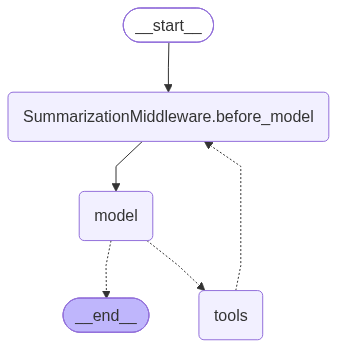

In [25]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Message summarization

agent= create_agent(
    model="groq:llama-3.3-70b-versatile", # main LLM to answer user's questions
    checkpointer=InMemorySaver(), #Stores the conversation state in memory so the agent remembers previous messages across turns (until the program exits). Without a checkpointer, the middleware cannot maintain conversation history for summarization.
    middleware=[ # Attaches one or more middleware to the agent.
        SummarizationMiddleware( # Its job is to prevent the conversation from growing indefinitely by replacing older messages with a summary.
            model="groq:llama-3.3-70b-versatile", # only used to generate the summary when summarization is triggered
            trigger=('messages',10), # This tells the middleware when the conversation reached 10 messages, summarize it
            keep=("messages",4) # This tells the middleware: After summarizing, keep the latest 4 messages unchanged.
        )
        ],
        tools=[get_weather] # just to see how the tool interacts with the middleware
)
# SummarizationMiddleware primarily reduces the number of input tokens sent to the main LLM on future turns.
agent



In [ ]:
#Run with thread id
config={"configurable": {"thread_id":"newnewthread"}}

# Alternative test data
questions =[
    "inventor of electricity",
    "founder of open ai",
    "Who is andrew ng",
    "What is fullform of OMG",
    "Why is earth round",
    "capital of delhi"
] ## total 6 questions

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='inventor of electricity', additional_kwargs={}, response_metadata={}, id='9c8a89d7-0422-429c-9360-fd24c1dfd59d'), AIMessage(content='The invention of electricity is a complex and multifaceted topic, and it is difficult to attribute its invention to a single person. However, some key figures who made significant contributions to the understanding and utilization of electricity include:\n\n1. Thales of Miletus (624-546 BCE): A Greek philosopher who is credited with being the first to study electricity, particularly the attractive properties of amber.\n2. William Gilbert (1544-1603): An English physician and scientist who coined the term "electricity" and published a book on the subject, "De Magnete," in 1600.\n3. Benjamin Franklin (1706-1790): An American statesman, scientist, and philosopher who conducted extensive research on electricity and demonstrated the connection between lightning and electricity.\n4. Alessandro Volta (1745-1827): An 

#### Limiting/Triggering based on TOKEN SIZE

In [27]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
1. Grand Hotel - 5 star, $350/night, spa, pool, gym
2. City Inn - 4 star, $180/night, business center
3. Budget Stay - 3 star, $75/night, free wifi"""

agent=create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.3-70b-versatile",
            trigger=("tokens", 550),
            keep=("tokens", 200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars = 1 token

In [28]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~243 tokens, 10 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='dff90389-093a-4d0b-9da3-8f09822daa64'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3d9sv8rg3', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 226, 'total_tokens': 241, 'completion_time': 0.036429861, 'completion_tokens_details': None, 'prompt_time': 0.012408188, 'prompt_tokens_details': None, 'queue_time': 0.056773651, 'total_time': 0.048838049}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8ee7-703b-7fb3-bffb-e5cc67cde0b9-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': '3d9sv8rg3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

### Human in the loop Middleware
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

* High-stakes operations requiring human approval (e.g. database writes, financial transactions).
* Compliance workflows where human oversight is mandatory.
* Long-running conversations where human feedback guides the agent.

Create an email agent that can read emails automatically, but before sending an email it must stop and wait for a human decision from the terminal.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

# Creating tools for the LLM to call
@tool
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [ ]:
agent = create_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(), # Stores the agent's state. This is required because the agent will pause, and the checkpoint should know where the agent stopped
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"] # ask the human before sending an email
                },
                "read_email_tool": False, # NO APPROVAL needed
            }
        )
    ],
)

In [ ]:
config = {"configurable": {"thread_id": "test-approve"}}

# Step 1: Request (starts the agent)
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="Send email to john@test.com with subject 'Hello' and body 'How are you?'"
            )
        ]
    },
    config=config,
)

In [ ]:
from langgraph.types import Command

# Step 2: Get manual human decision
if "__interrupt__" in result:
    print("⏸️ Agent paused. Human approval required.")

    decision = input(
        "Enter decision (approve/edit/reject): "
    ).strip().lower() # this waits for the human input

    if decision not in ["approve", "edit", "reject"]: # checks whether the user entered a valid option
        print("Invalid decision. Rejecting.") # fallback to an invalid entry is rejecting sending the mail
        decision = "reject"

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": decision}
                ]
            }
        ),
        config=config
    )

    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Agent paused. Human approval required.
✅ Result: I have sent an email to john@test.com with the subject 'Hello' and body 'How are you?'.


In [45]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='916d2079-f4a9-46bd-a4d2-162333cdaae8'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"subject": "Hello", "recipient": "john@test.com", "body": "How are you?"}'}, '__gemini_function_call_thought_signatures__': {'150e6b00-777e-49f6-b87c-1479234094c5': 'CqwCARFNMg83doaQ1RAG69BxWcoLj0I+2XEGOX7aOyE8Isfu4LMk4L0x8QPOEDM0nA3ljN3Lp6rv0sghPH8z4S26FsJ+Ts4JYcKSEdlqQ3H2BhVDfkBtvDsUG1z6jmXUwd1fGBRCIbZHvzmevC2M4XhIKUmGXL31PLb7g7uyPSh9mZ4fqEgsVnGcg5R7caC7dmmdyFDYFgKQTh75qZSzPypexX1v7BkdkQqXdtbhhhRwoHT9pdgEpNQJvn7oh3sYt2m94nkfyhf7K4Qq40oPj9cyS1rnyAm1APIOhMSVnxo/fe92PrzoVXdBCE7sJCjwCZmEyElu6KobdLi6Q/EU/MrzzuSvl4Jv6QAcuWYSYh6SGTCKiyP5HyjYFZh0kdhCAHCbN64l7lT89i4C/JYy'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'goog